In [ ]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "AnnualRainfall": np.random.randint(1500, 4000, 30),
    "FloodFrequency": np.random.choice(["Low", "Medium", "High"], 30),
    "LandslideFrequency": np.random.choice(["Low", "Medium", "High"], 30),
    "EarthquakeZone": np.random.choice(["Zone III", "Zone IV", "Zone V"], 30),
    "SlopeDegree": np.random.randint(5, 45, 30),
    "RiverDischarge": np.random.randint(50, 500, 30),
    "DamHeight": np.random.randint(20, 200, 30),
    "SedimentationRate": np.random.choice(["Low", "Medium", "High"], 30),
    "RiskLevel": np.random.choice(["Low", "Medium", "High"], 30)
})

df.head()


,AnnualRainfall,FloodFrequency,LandslideFrequency,EarthquakeZone,SlopeDegree,RiverDischarge,DamHeight,SedimentationRate,RiskLevel
0,2360,Medium,Medium,Zone III,44,85,140,Medium,High
1,2794,Medium,Medium,Zone V,26,62,135,High,High
2,2630,High,Medium,Zone III,31,209,22,Low,Medium
3,2595,Medium,Medium,Zone III,39,376,122,Low,High
4,3138,High,Medium,Zone III,5,236,174,Low,High


In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(['RiskLevel'], axis=1)
y = df['RiskLevel']

In [ ]:
X.head()

,AnnualRainfall,FloodFrequency,LandslideFrequency,EarthquakeZone,SlopeDegree,RiverDischarge,DamHeight,SedimentationRate
0,2360,Medium,Medium,Zone III,44,85,140,Medium
1,2794,Medium,Medium,Zone V,26,62,135,High
2,2630,High,Medium,Zone III,31,209,22,Low
3,2595,Medium,Medium,Zone III,39,376,122,Low
4,3138,High,Medium,Zone III,5,236,174,Low


In [ ]:
y.value_counts()

,count
RiskLevel,
High,12
Low,10
Medium,8


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


In [ ]:
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))


{'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [ ]:
label_encoder.classes_


array(['High', 'Low', 'Medium'], dtype=object)

In [ ]:
## Separate the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42,stratify=y_encoded)

In [ ]:
X_train.shape, X_test.shape

((24, 8), (6, 8))

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   AnnualRainfall      30 non-null     int64 
 1   FloodFrequency      30 non-null     object
 2   LandslideFrequency  30 non-null     object
 3   EarthquakeZone      30 non-null     object
 4   SlopeDegree         30 non-null     int64 
 5   RiverDischarge      30 non-null     int64 
 6   DamHeight           30 non-null     int64 
 7   SedimentationRate   30 non-null     object
dtypes: int64(4), object(4)
memory usage: 2.0+ KB


In [ ]:
# Create Column Transformer with 3 types of transformers

cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder', oh_transformer, cat_features),
        ('StandardScaler', numeric_transformer, num_features)
    ]
)

In [ ]:
# Apply Transformation in training set(fit_transform)
X_train = preprocessor.fit_transform(X_train)

In [ ]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.634717,0.599702,-0.600381,0.726662
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.026215,-0.933264,0.542970,1.429217
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,-1.036945,1.195855,0.887441,0.705999
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.643890,0.429372,0.154523,0.106761
4,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,-1.016474,1.025526,-0.145973,0.354721


In [ ]:
# Apply Transformation on test(transform)
X_test = preprocessor.transform(X_test)

In [ ]:
X_test

array([[ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  1.        ,  0.        ,  0.57212535, -2.04040592,
        -0.16796021,  1.22258343],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  1.25041889, -1.69974684,
        -1.20870272,  1.16059329],
       [ 1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.80140767,  0.34420761,
         0.53564037,  0.70599888],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        , -0.18668994, -0.16678101,
         0.11054835, -0.30650683],
       [ 0.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.35922034, -2.04040592,
        -0.29255614,  1.57386093],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  

XgBoost Classifier Training

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

models = {
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # TRAIN METRICS
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="macro")
    train_precision = precision_score(y_train, y_train_pred, average="macro")
    train_recall = recall_score(y_train, y_train_pred, average="macro")
    train_roc_auc = roc_auc_score(
        y_train, y_train_proba,
        multi_class="ovr", average="macro"
    )

    # TEST METRICS
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")
    test_precision = precision_score(y_test, y_test_pred, average="macro")
    test_recall = recall_score(y_test, y_test_pred, average="macro")
    test_roc_auc = roc_auc_score(
        y_test, y_test_proba,
        multi_class="ovr", average="macro"
    )

    print(f"\nModel: {name}")

    print("Training set performance")
    print(f"Accuracy: {train_accuracy:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall: {train_recall:.4f}")
    print(f"ROC AUC: {train_roc_auc:.4f}")

    print("\nTest set performance")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")



Model: XGBClassifier
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.3333
F1 Score: 0.3333
Precision: 0.3333
Recall: 0.3333
ROC AUC: 0.4583


In [ ]:
#key (name) value(model)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

models = {
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # TRAIN METRICS
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average="macro")
    train_precision = precision_score(y_train, y_train_pred, average="macro")
    train_recall = recall_score(y_train, y_train_pred, average="macro")
    train_roc_auc = roc_auc_score(
        y_train, y_train_proba,
        multi_class="ovr", average="macro"
    )

    # TEST METRICS
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")
    test_precision = precision_score(y_test, y_test_pred, average="macro")
    test_recall = recall_score(y_test, y_test_pred, average="macro")
    test_roc_auc = roc_auc_score(
        y_test, y_test_proba,
        multi_class="ovr", average="macro"
    )

    print(f"\nModel: {name}")

    print("Training set performance")
    print(f"Accuracy: {train_accuracy:.4f}")
    print(f"F1 Score: {train_f1:.4f}")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall: {train_recall:.4f}")
    print(f"ROC AUC: {train_roc_auc:.4f}")

    print("\nTest set performance")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"F1 Score: {test_f1:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"ROC AUC: {test_roc_auc:.4f}")


In [ ]:
print(confusion_matrix(y_test, y_test_pred))


[[0 1 1]
 [0 1 1]
 [1 1 0]]


In [ ]:
# Hyperparameter tuning
xb_params = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7 , 15, 30],
    'n_estimators': [100, 200, 500, 1000],
    'colsample_bytree': [0.3, 0.5, 0.7, 1]
}

In [ ]:
xb_params

{'learning_rate': [0.01, 0.1, 0.3],
 'max_depth': [3, 5, 7, 15, 30],
 'n_estimators': [100, 200, 500, 1000],
 'colsample_bytree': [0.3, 0.5, 0.7, 1]}

In [ ]:
# Models list for hyperparameter tuning
randomcv_models = [
    ('XGBClassifier', XGBClassifier(), xb_params)
]

In [ ]:
randomcv_models

[('XGBClassifier',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric=None, feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=None, num_parallel_tree=None, ...),
  {'learning_rate': [0.01, 0.1, 0.3],
   'max_depth': [3, 5, 7, 15, 30],
   'n_estimators': [100, 200, 500, 1000],
   'colsample_bytree': [0.3, 0.5, 0.7, 1]})]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}

for name, model, param in randomcv_models:
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=xb_params,
        n_iter=100,
        cv=3,
        verbose=2,
        n_jobs=-1
    )
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"------------------Best Parameters for {model_name}------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
------------------Best Parameters for XGBClassifier------------------
{'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.3}


In [ ]:
models = {
    "XGBClassifier": XGBClassifier(colsample_bytree=0.3, learning_rate=0.01, max_depth=5, n_estimators=500, objective="multi:softprob", num_class=3, eval_metric="mlogloss", random_state=42),
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train the model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Get probability predictions
    y_train_proba = model.predict_proba(X_train)
    y_test_proba = model.predict_proba(X_test)

    # Training set performance
    mode_train_accuracy = accuracy_score(y_train, y_train_pred) # calculate accuracy
    model_train_f1 = f1_score(y_train, y_train_pred,average="macro") # calculate f1 score
    model_train_precision = precision_score(y_train, y_train_pred,average="macro") # calculate precision
    model_train_recall = recall_score(y_train, y_train_pred,average="macro") # calculate recall
    model_train_roc_auc = roc_auc_score(y_train, y_train_proba,
        multi_class="ovr", average="macro") # calculate roc_auc

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # calculate accuracy
    model_test_f1 = f1_score(y_test, y_test_pred,average="macro") # calculate f1 score
    model_test_precision = precision_score(y_test, y_test_pred,average="macro") # calculate precision
    model_test_recall = recall_score(y_test, y_test_pred,average="macro") # calculate recall
    model_test_roc_auc = roc_auc_score(y_test, y_test_proba,
        multi_class="ovr", average="macro") # calculate roc_auc

    print(f"Model: {list(models.keys())[i]}")

    print("Training set performance")
    print("Accuracy: {:.4f}".format(mode_train_accuracy))
    print("F1 Score: {:.4f}".format(model_train_f1))
    print("Precision: {:.4f}".format(model_train_precision))
    print("Recall: {:.4f}".format(model_train_recall))
    print("ROC AUC: {:.4f}".format(model_train_roc_auc))

    print("\nTest set performance")
    print("Accuracy: {:.4f}".format(model_test_accuracy))
    print("F1 Score: {:.4f}".format(model_test_f1))
    print("Precision: {:.4f}".format(model_test_precision))
    print("Recall: {:.4f}".format(model_test_recall))
    print("ROC AUC: {:.4f}\n".format(model_test_roc_auc))

Model: XGBClassifier
Training set performance
Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC AUC: 1.0000

Test set performance
Accuracy: 0.1667
F1 Score: 0.1333
Precision: 0.1111
Recall: 0.1667
ROC AUC: 0.4167



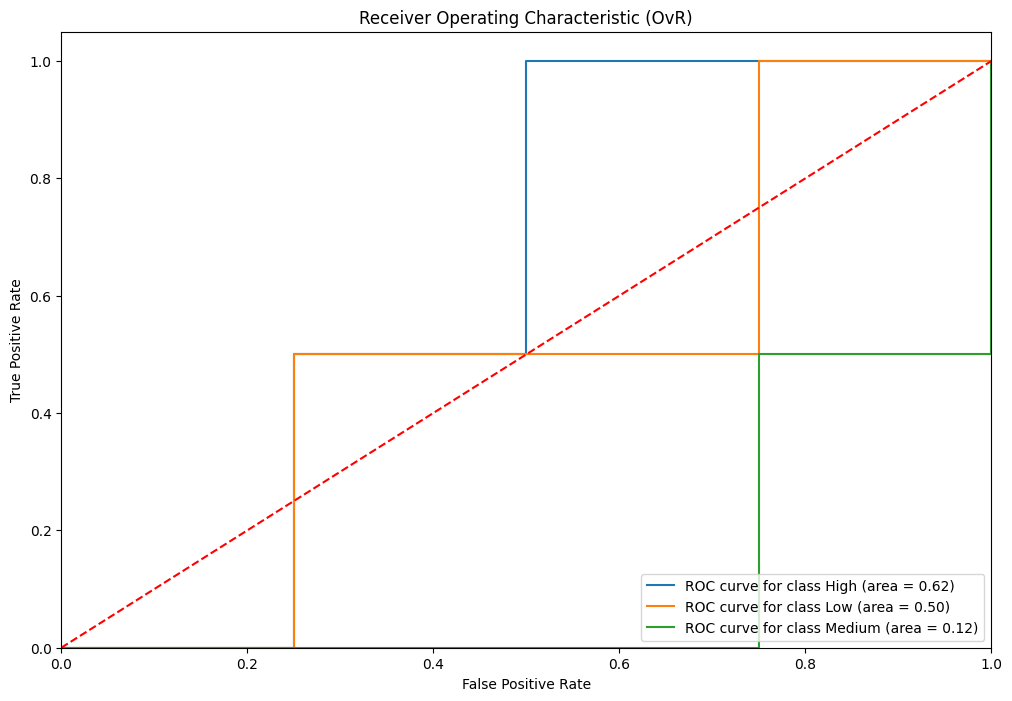

In [ ]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

# Use the best model found from hyperparameter tuning (assuming 'model_param' is available)
# The best parameters from previous execution were {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.3}
# Assuming label_encoder is also available from previous steps
best_xgb_model = XGBClassifier(
    colsample_bytree=0.3,
    learning_rate=0.01,
    max_depth=5,
    n_estimators=500,
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42
)
best_xgb_model.fit(X_train, y_train)

# Get predicted probabilities for the test set
y_test_proba = best_xgb_model.predict_proba(X_test)

# Binarize the true labels for OvR plotting
y_test_binarized = label_binarize(y_test, classes=np.unique(y_encoded))

# Get class labels for plotting from the original label_encoder
class_labels = label_encoder.classes_

# Plot ROC curve for each class (One-vs-Rest)
for i, class_id in enumerate(np.unique(y_encoded)):
    # Calculate FPR, TPR for the current class
    fpr, tpr, thresholds = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])

    # Calculate AUC for the current class
    class_auc = roc_auc_score(y_test_binarized[:, i], y_test_proba[:, i])

    plt.plot(fpr, tpr, label=f'ROC curve for class {class_labels[i]} (area = {class_auc:.2f})')

# Custom settings for the plot
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (OvR)')
plt.legend(loc="lower right")
plt.savefig("AUC_multiclass.png")
plt.show()


Obtain More Data: The most effective solution for overfitting and poor generalization on small datasets is to acquire more data. If possible, expanding the dataset would significantly improve model performance and reliability.

Simplify the Model: XGBoost is a powerful but complex model. For a dataset this small, it tends to overfit easily. Consider trying a simpler model, such as Logistic Regression or a Decision Tree with very limited depth. These models have fewer parameters and are less prone to overfitting small datasets.

Implement Robust Cross-Validation: While RandomizedSearchCV uses cross-validation internally, the final evaluation on a tiny test set (6 samples) is still very unstable. For small datasets, techniques like K-Fold Cross-Validation or Stratified K-Fold Cross-Validation (since your classes are imbalanced) can provide a more reliable estimate of model performance. You can train and evaluate the model multiple times on different splits of the data and average the results.

Feature Engineering/Selection: Review your features. Are all of them truly informative for predicting 'RiskLevel'? With a small dataset, every feature counts, and sometimes too many features (relative to samples) can lead to overfitting. You might consider feature selection techniques if you suspect some features are not contributing positively.